### Prepare data

a bunch of sine waves with different trends, but same frequencies and phases


In [1]:
# basic imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
import pathlib
import random
import sklearn.linear_model
import torch
import torch.nn as nn
from torch.nn.modules.transformer import MultiheadAttention
from torch.optim.lr_scheduler import LambdaLR

#import utils
#import importlib
#_ = importlib.reload(utils)

if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using GPU:", device)
else:
    device = torch.device("cpu")
    print("No GPU -> using CPU:", device)

import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'


No GPU -> using CPU: cpu


/home/markus/.local/lib/python3.12/site-packages/torch/cuda/__init__.py:129: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0


In [2]:
# prepare sine waves for forecasting

num_datasets=50                     # vary trend (slope) and intercept
num_freq = 4                        # vary frequency
num_features=1                      # stick to univariate data right now
num_points_in_each_dataset=512+96   # fit for TTM 512_96

# for later tuning
hyperparameters = {'output_noise': 0.01, 'variance_weights': 1.0, 'scaling': .2, 'trend': 2, 'base_frequency': 11}

# shape (150,8) normally distributed around mean 0 for fourier like coefficients - univariate * (4 sine + 4*cosine)
four = torch.distributions.Normal(torch.zeros(num_features*8), hyperparameters['variance_weights']).sample((num_datasets*num_freq,))


# do it in more orderly fashion
ws = torch.zeros(num_datasets, 2)
ws[:,0] = torch.arange(-hyperparameters['trend'], hyperparameters['trend'], 
                       step=2*hyperparameters['trend']/num_datasets, dtype=torch.float) + \
        torch.sigmoid(torch.arange(0, 10, step=10/num_datasets, dtype=torch.float))
ws[:,1] = 0.5

#xs = torch.rand(num_datasets, num_points_in_each_dataset, num_features)

xs = torch.meshgrid(torch.arange(num_datasets, dtype=torch.float), 
                    torch.arange(0, 2 * np.pi, step=2 * np.pi/num_points_in_each_dataset, dtype=torch.float),
                    torch.arange(num_features, dtype=torch.float))[1]

# concat meshgrid with 1-matrix before multiplying elementwise xs*ws[0](slope) + ws[1](constant) for each of the 50 datasets
xxxs =  torch.einsum('nmf, nf -> nm',
                 torch.cat([xs, torch.ones(num_datasets, num_points_in_each_dataset,1)], 2),
                 ws
                )

# vary frequency
xgrid_ = []
xargs_ = []
for i in range(num_freq):
    xargs_.append(xs * (i+1))
    xgrid_.append(xxxs)

slope = torch.cat(xgrid_,0)
xargs = torch.cat(xargs_,0).squeeze()
'''
# Don't need it now
ys = torch.distributions.Normal(
    torch.einsum('nmf, nf -> nm',
                 torch.cat([xs, torch.ones(num_datasets, num_points_in_each_dataset,1)], 2),
                 ws
                ),
    hyperparameters['output_noise']
).sample()
'''

multiplier = hyperparameters['base_frequency']


print(four.shape, torch.stack([torch.sin(xargs * multiplier), torch.cos(xargs * multiplier)]).shape)
#zs = xxxs + torch.sin(xs.squeeze() * 17) * hyperparameters['scaling']
# use 

sincos = torch.stack([torch.sin(xargs * multiplier), torch.cos(xargs * multiplier), 
                        torch.sin(xargs * multiplier * 1.5), torch.cos(xargs * multiplier * 1.5),
                        torch.sin(xargs * multiplier * 2), torch.cos(xargs * multiplier * 2),
                        torch.sin(xargs * multiplier * 2.5), torch.cos(xargs * multiplier * 2.5)])
signal = torch.einsum('ijk, ji -> jk', sincos, four) * hyperparameters['scaling']
zs = slope + signal #torch.sin(xargs.squeeze() * 17) * hyperparameters['scaling']
#zs = zs.diff()

/home/markus/.local/lib/python3.12/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


torch.Size([200, 8]) torch.Size([2, 200, 608])


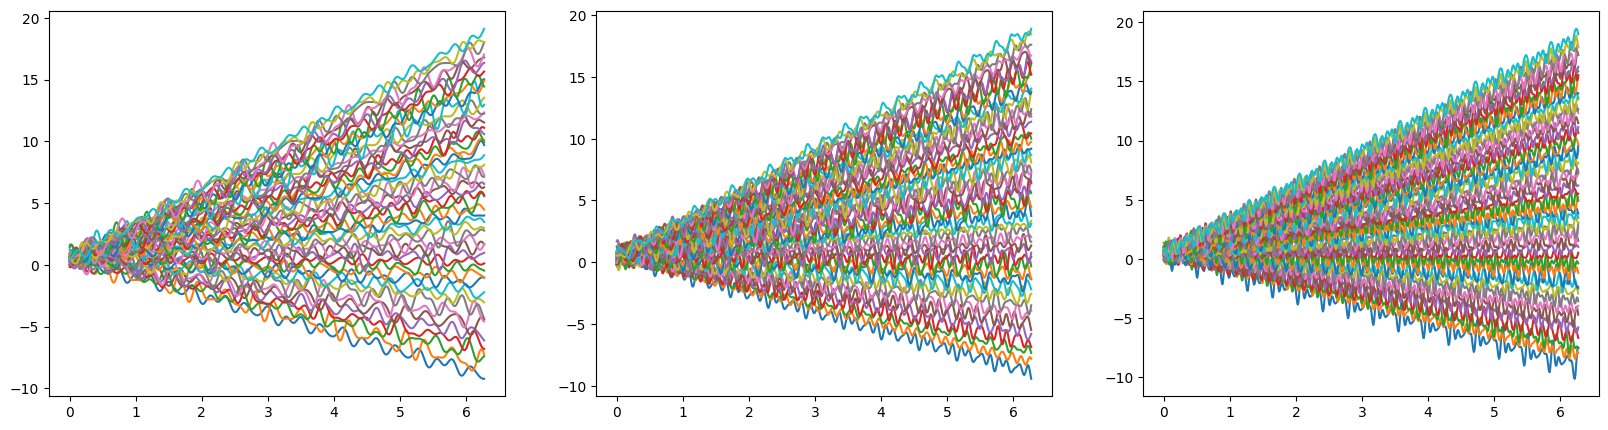

In [3]:
fig,ax = plt.subplots(1,3,figsize=(20,5))
for idx in range(0,50): #range(num_datasets):
    ax[0].plot(xs[idx,:,0].numpy(), zs[idx].numpy())
    ax[1].plot(xs[idx,:,0].numpy(), zs[idx+num_datasets].numpy())
    ax[2].plot(xs[idx,:,0].numpy(), zs[idx+num_datasets*2].numpy()) 

### Try with TTM first

In [5]:
# redefine our loss function 
def trend_loss(targets,outputs,alpha=0.5,device='cpu'):
    sq_error = w_mse2(targets,outputs,device)

    #print('sq_error', sq_error.shape)

    error1=torch.mean(sq_error, dim=-1)

    x1 = derivatives2(targets, device)
    x2 = derivatives2(outputs, device)

    # center by rows first
    _xt1 = x1.squeeze()
    _xt2 = x2.squeeze()

    #print('XT1',_xt1.shape)
    if len(_xt1.shape) == 1:
        _xt1 = torch.reshape(_xt1,(1,_xt1.shape[0]))

    batch_size, lens = _xt1.shape[0:2]
    #print('SQUEEZE reshape', batch_size, lens)

    _xcentered1 = None
    _xcentered2 = None
    if len(_xt1.shape) > 1:
        _xt1 = _xt1.T
        _xt2 = _xt2.T
        _xcentered1 = (_xt1 - _xt1.mean(dim=0)).T
        _xcentered2 = (_xt2 - _xt2.mean(dim=0)).T
    else:
        _xcentered1 = _xt1 - _xt1.mean()
        _xcentered2 = _xt2 - _xt2.mean()
        
    p_corr = torch.nn.functional.cosine_similarity(_xcentered1, _xcentered2, dim=-1)

    w_corr = 1 - p_corr

    dd = torch.norm(targets - outputs, dim=-1)

    d_error = w_corr * dd

    return error1 + alpha * d_error


def w_mse2(targets,outputs,device='cpu'):

    delta=0.00000001
    batch_size, lens = targets.shape[0:2]

    target1= targets[:,1:lens].to(device)
    target2= targets[:,0:lens-1].to(device)
    output1 = outputs[:, 1:lens].to(device)
    output2 = outputs[:, 0:lens - 1].to(device)
    
    sigma_matrix=(target1-target2)*(output1-output2).to(device)

    # paper proposes tanh, but the author's implementation resorts to simple signum
    # sigma=torch.sign(sigma_matrix).to(device)
    sigma=torch.tanh(sigma_matrix).to(device)
    

    newtargets=targets[:,1:lens].to(device)
    newoutputs=outputs[:,1:lens].to(device)

    #print(sigma_matrix)
    
    #W1 = 1.01 + torch.abs(newoutputs-newtargets)/(torch.abs(newoutputs+newtargets)+delta)
    #W2 = (1.0 - sigma)
    #W3 = W1 ** W2
    
   
    #W=(1.01+torch.abs(newoutputs-newtargets)/(torch.abs(newoutputs+newtargets)+delta))**(1.0-sigma).to(device)
    W=torch.abs(newoutputs-newtargets)*(1.0-sigma).to(device)
    #print(sigma)

    #w_error=W*torch.abs(newoutputs-newtargets)
    w_error = W

    return w_error

def derivatives2(Input,device='cpu'):

    batch_size,lens =Input.shape[0:2]

    input2 = Input[:,2:lens].to(device)
    input1 = Input[:,0:lens-2].to(device)

    return input2 - input1
    

In [6]:
from tsfm_public.models.tinytimemixer import TinyTimeMixerForPrediction
model = TinyTimeMixerForPrediction.from_pretrained("ibm/TTM", cache_dir='/tmp', revision="main")

config.json:   0%|          | 0.00/1.19k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.24M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/69.0 [00:00<?, ?B/s]

In [7]:
# I'm not sure whether this is the right way to specify frequency patterns for TTM 
freq = torch.sin(xs[...,0]*17)[0]

# and the public model doesn't support it as you can see
model.decoder.resolution_prefix_tuning, model.backbone.encoder.resolution_prefix_tuning

(False, False)

In [8]:

#zhat = model(zs[:,:512,None], freq_token=freq)['prediction_outputs']
zhat = model(zs[:,:512,None])['prediction_outputs']

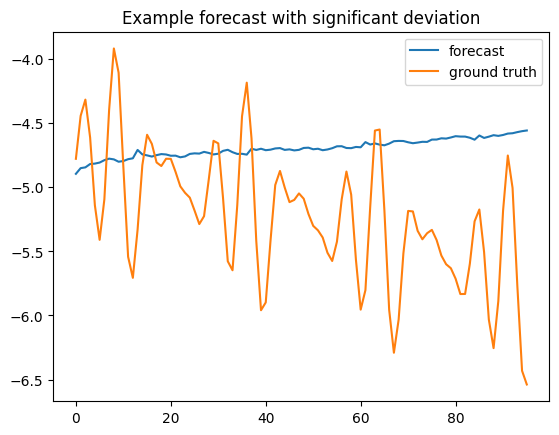

In [9]:
i_dev = 154
zhat.shape, zs.shape
plt.plot(zhat[i_dev,:].detach().numpy(), label='forecast')
plt.plot(zs[i_dev,512:].detach().numpy(), label='ground truth')
plt.title('Example forecast with significant deviation')
plt.legend()

In [10]:
from cbm_gen.utils.benchmarks.evaluation import tildeq_loss # trend_loss, tildeq_loss
#mse_loss = torch.nn.MSELoss()
loss_trend = trend_loss(zhat.squeeze(), zs[:,512:])
loss_tildeq = tildeq_loss(zhat.squeeze(), zs[:,512:])
loss_mse = torch.norm(zhat.squeeze() - zs[:,512:], dim=1)


/home/markus/.local/lib/python3.12/site-packages/genai/extensions/langchain/__init__.py:9: LangChainDeprecationWarning: As of langchain-core 0.3.0, LangChain uses pydantic v2 internally. The langchain_core.pydantic_v1 module was a compatibility shim for pydantic v1, and should no longer be used. Please update the code to import from Pydantic directly.

For example, replace imports like: `from langchain_core.pydantic_v1 import BaseModel`
with: `from pydantic import BaseModel`
or the v1 compatibility namespace if you are working in a code base that has not been fully upgraded to pydantic 2 yet. 	from pydantic.v1 import BaseModel

  from genai.extensions.langchain.chat_llm import LangChainChatInterface, LangChainChatFunctions


In [11]:
#loss_mse[149], loss_mse[99]

In [12]:
# find the best and worst match according to TildeQ - usually trend and tilde-q agree
bad_idx = loss_tildeq.argmax().detach().item()
good_idx = loss_tildeq.argmin().detach().item()
bad_idx = loss_trend.argmax().detach().item()
good_idx = loss_trend.argmin().detach().item()
print('Trend: worst', bad_idx, 'best', good_idx, '\nTildeq: worst', loss_tildeq.argmax().detach().item(),
      'best', loss_tildeq.argmin().detach().item(), '\nMSE: worst', loss_mse.argmax().detach().item(),
      'best', loss_mse.argmin().detach().item())
# surprisingly the plain sine wave is doing less well than a sine wave with a very slight trend

Trend: worst 94 best 18 
Tildeq: worst 93 best 113 
MSE: worst 94 best 113


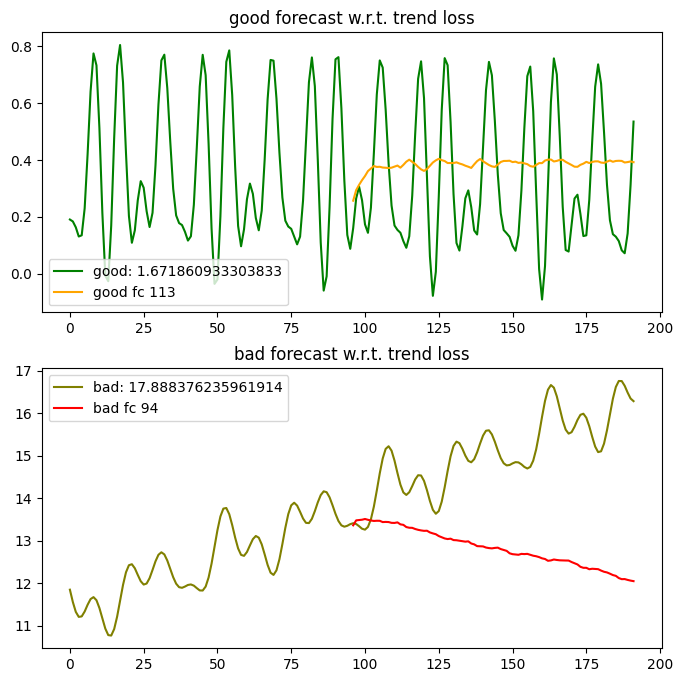

In [18]:
#good_idx = 113
#bad_idx = 75
startat = 512-96
tpl = np.zeros(512).reshape(-1,1)
tpl[:] = np.nan
good = np.vstack((tpl,zhat[good_idx].detach().numpy()))
bad = np.vstack((tpl,zhat[bad_idx].detach().numpy()))

fig, ax = plt.subplots(2,1,figsize=(8,8))
ax[0].set_title('good forecast w.r.t. trend loss')
ax[0].plot(range(512-startat+96), zs[good_idx,startat:].detach().numpy(), label='good: ' + str(loss_trend[good_idx].detach().item()),c='g')
ax[0].plot(range(512-startat+96), good[startat:], label='good fc ' + str(good_idx), c='orange')
ax[1].set_title('bad forecast w.r.t. trend loss')
ax[1].plot(range(512-startat+96), zs[bad_idx,startat:].detach().numpy(), label='bad: ' + str(loss_trend[bad_idx].detach().item()), c='olive')
ax[1].plot(range(512-startat+96), bad[startat:], label='bad fc ' + str(bad_idx), c='red')
ax[0].legend()
ax[1].legend()

Text(0.5, 1.0, "TTM forecasting in general doesn't do well with non-stationary time series")

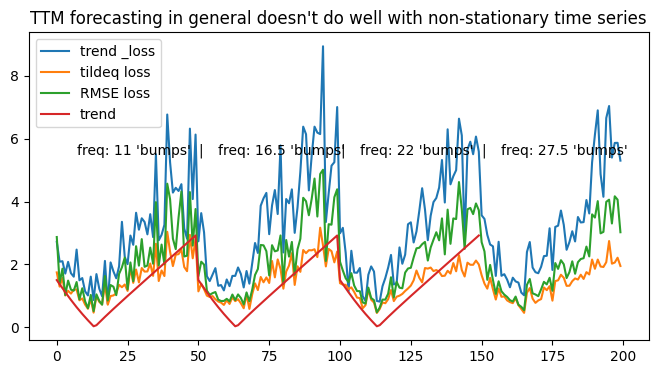

In [14]:
text_y = 5.5
bf = hyperparameters['base_frequency']
fig,ax = plt.subplots(1,1,figsize=(8,4))
#plt.plot(zhat[bad_idx].detach().numpy())
#plt.plot(zs[bad_idx,512:].detach().numpy())
ax.plot(loss_trend.clip(0,30).detach().numpy()/2, label='trend _loss')
ax.plot(loss_tildeq.detach().numpy(), label='tildeq loss')
ax.plot(loss_mse.detach().numpy()/5, label='RMSE loss')
#ax.scatter([50,100], [0.5,0.5], s=30, c='red', marker='|')
ax.plot(torch.cat([abs(ws), abs(ws), abs(ws)]).detach().numpy()[:,0], label='trend')
ax.text(7,text_y,'freq: ' + str(bf) + ' \'bumps\'')
ax.text(50,text_y,'|')
ax.text(57,text_y,'freq: ' + str(bf*1.5) + ' \'bumps\'')
ax.text(100,text_y,'|')
ax.text(107,text_y,'freq: ' + str(bf * 2) + ' \'bumps\'')
ax.text(150,text_y,'|')
ax.text(157,text_y,'freq: ' + str(bf * 2.5) + ' \'bumps\'')
ax.legend()
ax.set_title('TTM forecasting in general doesn\'t do well with non-stationary time series')

### Investigate trends

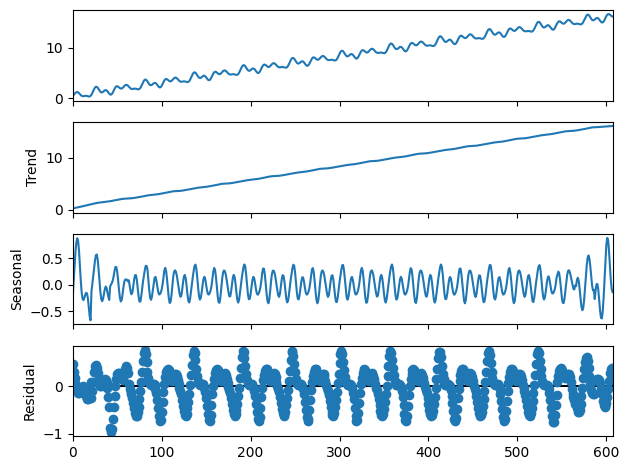

In [99]:
'''
from trendfilter import trend_filter, get_example_data, plot_model
#result = trend_filter(x, y_noisy, l_norm=1, alpha_2=4.0, linear_deviations=linear_deviations)
#zhat[good_idx]
result = trend_filter(np.arange(512 + 96), zs[bad_idx].detach().numpy(), l_norm=1, alpha_2=10.0)
#plot_model(result, show_extrap=True, extrap_max=40, show_base=True)
'''
from statsmodels.tsa.seasonal import STL

stl = STL(zs[bad_idx], period=21, robust=True)
res = stl.fit()
fig = res.plot()

In [100]:
trend = torch.Tensor(res.trend)
season = torch.Tensor(res.seasonal)
resid = torch.Tensor(res.resid)

trend_hat = model(trend[None,:512,None])['prediction_outputs']
season_hat = model(season[None,:512,None])['prediction_outputs']
resid_hat = model(resid[None,:512,None])['prediction_outputs']

#zhat = model(torch.Tensor(zs[:,:512,None])['prediction_outputs']

In [126]:
#tr_loss = trend_loss(season_hat.reshape(1,-1), season.reshape(1,-1)[:, 512:])
ti_trend_loss = trend_loss(trend_hat.reshape(1,-1), trend.reshape(1,-1)[:, 512:])
ti_season_loss = trend_loss(season_hat.reshape(1,-1), season.reshape(1,-1)[:, 512:])
ti_resid_loss = trend_loss(resid_hat.reshape(1,-1), resid.reshape(1,-1)[:, 512:])
#trend_loss(trend_hat[None,:], trend[None,512:])
ti_trend_loss, ti_season_loss, ti_resid_loss, loss_trend[bad_idx]

(tensor([7.0184], grad_fn=<AddBackward0>),
 tensor([2.2779], grad_fn=<AddBackward0>),
 tensor([2.4178], grad_fn=<AddBackward0>),
 tensor(17.8884, grad_fn=<SelectBackward0>))

Text(0.5, 1.0, 'residual - loss = 2.4177918434143066')

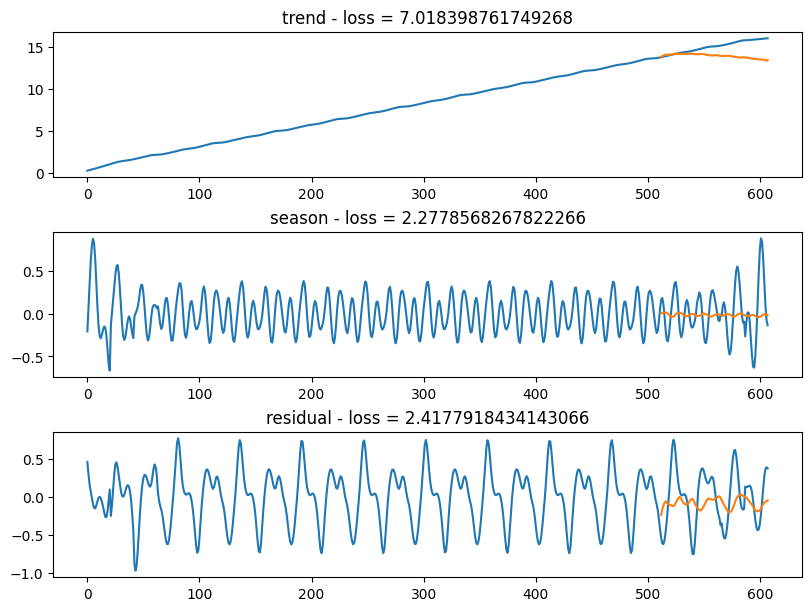

In [127]:
fig, ax = plt.subplots(3,1,figsize=(8,6), layout='constrained')
ax[0].plot(res.trend)
ax[0].plot(np.vstack((tpl, trend_hat.detach().numpy().reshape(-1,1))))
ax[0].set_title('trend - loss = ' + str(ti_trend_loss.detach().item()))
ax[1].plot(res.seasonal)
ax[1].plot(np.vstack((tpl, season_hat.detach().numpy().reshape(-1,1))))
ax[1].set_title('season - loss = ' + str(ti_season_loss.detach().item()))
ax[2].plot(res.resid)
ax[2].plot(np.vstack((tpl, resid_hat.detach().numpy().reshape(-1,1))))
ax[2].set_title('residual - loss = ' + str(ti_resid_loss.detach().item()))


### Differencing to eliminate the linear component of the trend

We also scale up by 10.


In [664]:

zs_diff = torch.cat([zs, zs[:,-1:]], dim=-1)
zs_diff = zs_diff.diff(dim=-1)*10

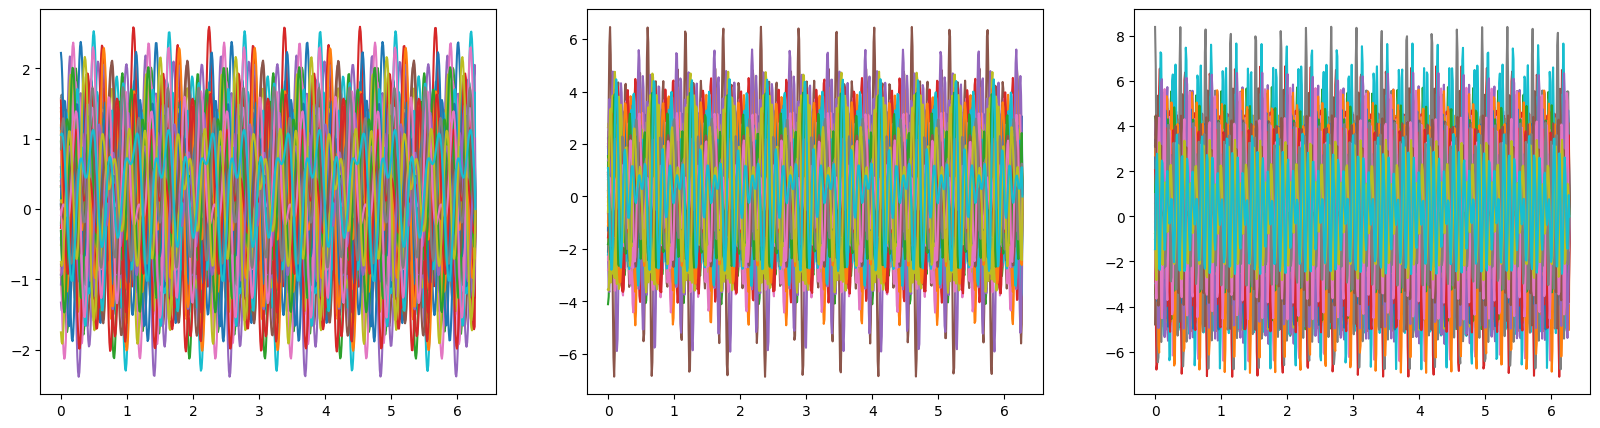

In [665]:
fig,ax = plt.subplots(1,3,figsize=(20,5))
for idx in range(0,50): #range(num_datasets):
    ax[0].plot(xs[idx,:,0].numpy(), zs_diff[idx].numpy())
    ax[1].plot(xs[idx,:,0].numpy(), zs_diff[idx+num_datasets].numpy())
    ax[2].plot(xs[idx,:,0].numpy(), zs_diff[idx+num_datasets*2].numpy()) 

In [666]:
zdiff_hat = model(zs_diff[:,:512,None])['prediction_outputs']

In [667]:
lossd_trend = trend_loss2(zdiff_hat.squeeze(), zs_diff[:,512:])
lossd_tildeq = tildeq_loss(zdiff_hat.squeeze(), zs_diff[:,512:])
lossd_mse = torch.norm(zdiff_hat.squeeze() - zs_diff[:,512:], dim=1)



In [668]:
# find the best and worst match according to TildeQ - usually trend and tilde-q agree
badd_idx = lossd_tildeq.argmax().detach().item()
goodd_idx = lossd_tildeq.argmin().detach().item()
badd_idx = lossd_trend.argmax().detach().item()
goodd_idx = lossd_trend.argmin().detach().item()
badd_idx, goodd_idx, lossd_tildeq.argmax(), lossd_tildeq.argmin(), lossd_mse.argmax(), lossd_mse.argmin()

(177, 38, tensor(137), tensor(38), tensor(174), tensor(38))

#### Results

It still doesn't like all frequency mixes, if the dominant frequencies are to high TTM forecasts some sort of 'average'

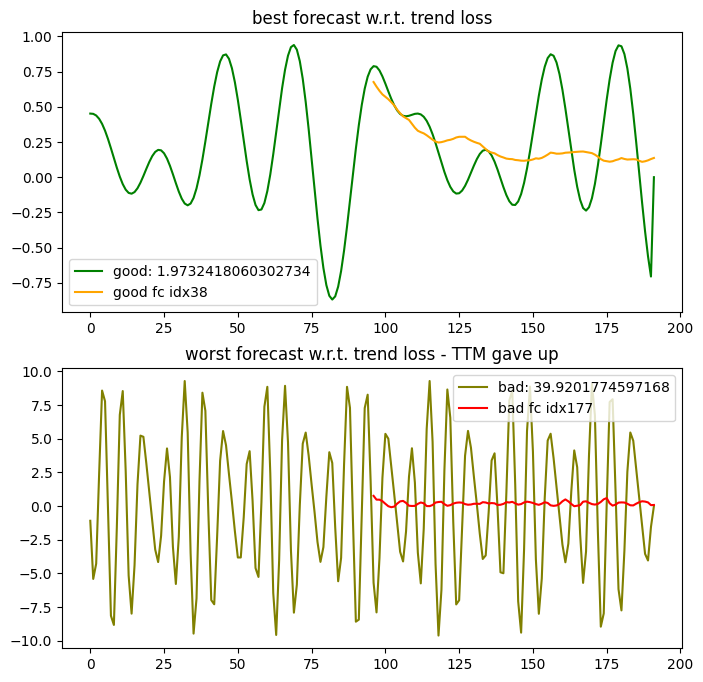

In [669]:
#badd_idx = 51
startat = 512-96
tpl = np.zeros(512).reshape(-1,1)
tpl[:] = np.nan
good = np.vstack((tpl,zdiff_hat[goodd_idx].detach().numpy()))
bad = np.vstack((tpl,zdiff_hat[badd_idx].detach().numpy()))

fig, ax = plt.subplots(2,1,figsize=(8,8))
ax[0].set_title('best forecast w.r.t. trend loss')
ax[0].plot(range(512-startat+96), zs_diff[goodd_idx,startat:].detach().numpy(), label='good: ' + str(lossd_trend[goodd_idx].detach().item()),c='g')
ax[0].plot(range(512-startat+96), good[startat:], label='good fc idx' + str(goodd_idx), c='orange')
ax[1].set_title('worst forecast w.r.t. trend loss - TTM gave up')
ax[1].plot(range(512-startat+96), zs_diff[badd_idx,startat:].detach().numpy(), label='bad: ' + str(lossd_trend[badd_idx].detach().item()), c='olive')
ax[1].plot(range(512-startat+96), bad[startat:], label='bad fc idx' + str(badd_idx), c='red')
ax[0].legend()
ax[1].legend()

Text(0.5, 1.0, 'Small non-linear trend, random harmonics')

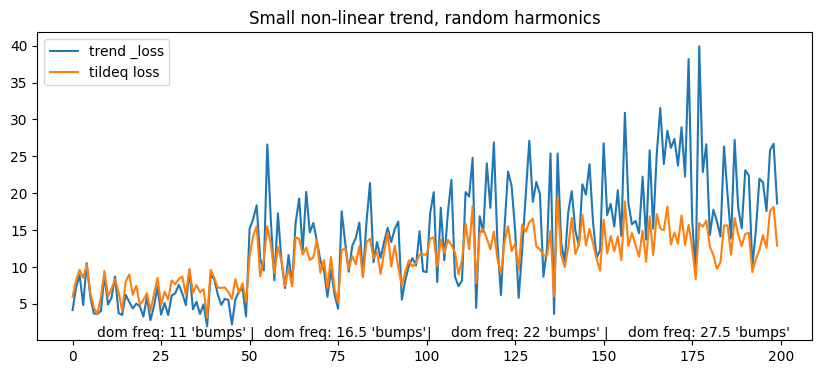

In [681]:
text_y = 0.5
bf = hyperparameters['base_frequency']
fig,ax = plt.subplots(1,1,figsize=(10,4))

ax.plot(lossd_trend.detach().numpy(), label='trend _loss')
ax.plot(lossd_tildeq.detach().numpy()*5, label='tildeq loss')
#ax.plot(lossd_mse.detach().numpy()/3, label='RMSE loss')
#ax.scatter([50,100], [0.5,0.5], s=30, c='red', marker='|')
#ax.plot(torch.cat([abs(ws), abs(ws), abs(ws)]).detach().numpy()[:,0], label='trend')
ax.text(7,text_y,'dom freq: ' + str(bf) + ' \'bumps\'')
ax.text(50,text_y,'|')
ax.text(54,text_y,'dom freq: ' + str(bf*1.5) + ' \'bumps\'')
ax.text(100,text_y,'|')
ax.text(107,text_y,'dom freq: ' + str(bf*2) + ' \'bumps\'')
ax.text(150,text_y,'|')
ax.text(157,text_y,'dom freq: ' + str(bf*2.5) + ' \'bumps\'')
ax.legend()
ax.set_title('Small non-linear trend, random harmonics')

In [671]:
lossd_trend[191]

tensor(22.4161, grad_fn=<SelectBackward0>)

#### Conclusion

Findings, especially TSFM's sensitivity to frequencies, is well known and described in the following article

https://arxiv.org/abs/2411.15743v1

This article proposes a framework to ensure that "the train set should span the predominant frequencies of the target domain". This framework allows to generate synthetic data sharing its dominant frequencies with those of the target domain.

### Upsampling

to lower the dominant frequency



In [628]:
Resampler = torch.nn.Upsample(scale_factor=2, mode='linear')
zs_diff[None,:,:].shape
zs_diff_samp = Resampler(zs_diff[None,:,:])

In [640]:
zs_diff_samp = zs_diff_samp.squeeze()
#

torch.Size([200, 1216])

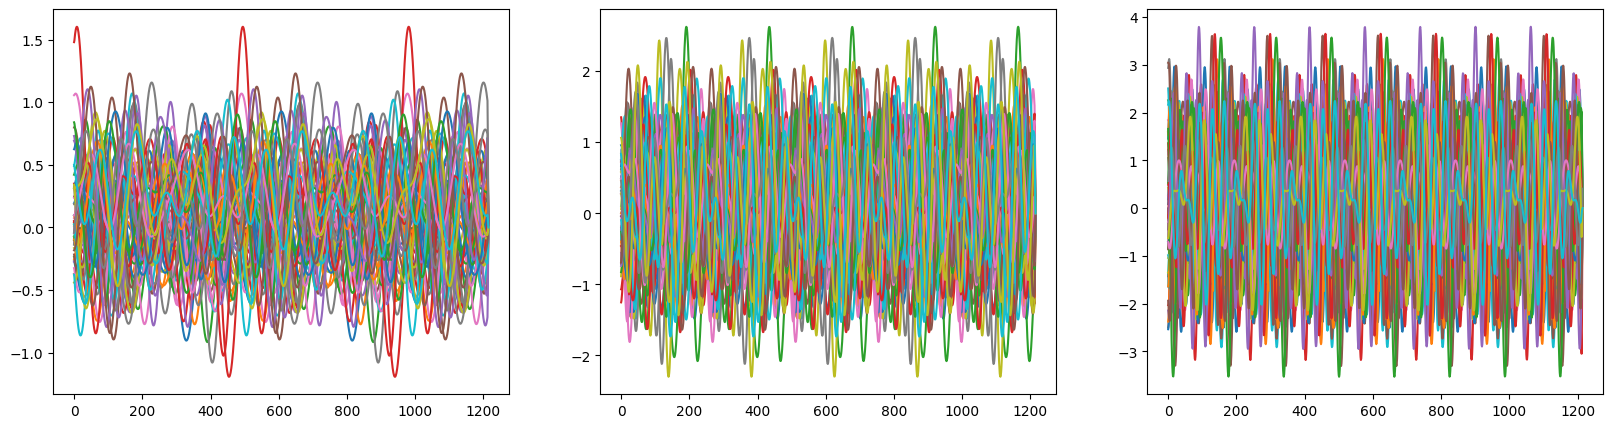

In [635]:
fig,ax = plt.subplots(1,3,figsize=(20,5))
for idx in range(0,50): #range(num_datasets):
    ax[0].plot(zs_diff_samp[idx].numpy())
    ax[1].plot(zs_diff_samp[idx+num_datasets].numpy())
    ax[2].plot(zs_diff_samp[idx+num_datasets*2].numpy()) 

In [636]:
zdiff_samp_hat = model(zs_diff_samp[:,-608:-96,None])['prediction_outputs']

In [641]:
lossd_trend = trend_loss2(zdiff_samp_hat.squeeze(), zs_diff_samp[:,-96:])
lossd_tildeq = tildeq_loss(zdiff_samp_hat.squeeze(),zs_diff_samp[:,-96:])
lossd_mse = torch.norm(zdiff_samp_hat.squeeze() - zs_diff_samp[:,-96:], dim=1)

Text(0.5, 1.0, 'Small non-linear trend, random harmonics')

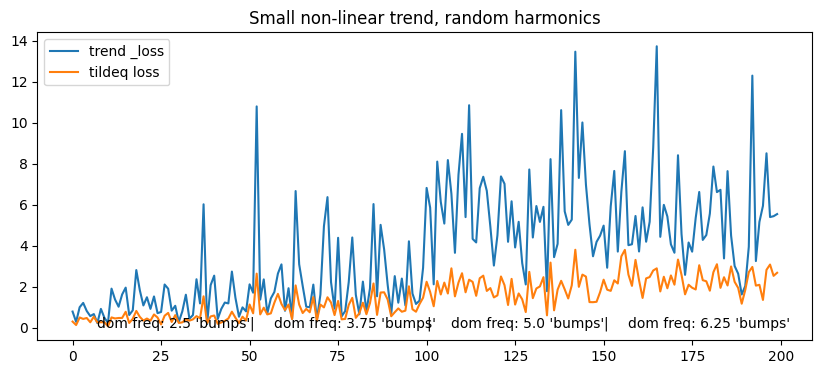

In [642]:
text_y = 0.0
bf = hyperparameters['base_frequency']
fig,ax = plt.subplots(1,1,figsize=(10,4))

ax.plot(lossd_trend.detach().numpy(), label='trend _loss')
ax.plot(lossd_tildeq.detach().numpy(), label='tildeq loss')
#ax.plot(lossd_mse.detach().numpy()/3, label='RMSE loss')
#ax.scatter([50,100], [0.5,0.5], s=30, c='red', marker='|')
#ax.plot(torch.cat([abs(ws), abs(ws), abs(ws)]).detach().numpy()[:,0], label='trend')
ax.text(7,text_y,'dom freq: ' + str(bf/2) + ' \'bumps\'')
ax.text(50,text_y,'|')
ax.text(57,text_y,'dom freq: ' + str(bf*1.5/2) + ' \'bumps\'')
ax.text(100,text_y,'|')
ax.text(107,text_y,'dom freq: ' + str(bf*2/2) + ' \'bumps\'')
ax.text(150,text_y,'|')
ax.text(157,text_y,'dom freq: ' + str(bf*2.5/2) + ' \'bumps\'')
ax.legend()
ax.set_title('Small non-linear trend, random harmonics')

In [ ]:
### Conclusion

While 

In [134]:
'''
fig, ax = plt.subplots(1,1,figsize=(10,5))
ax.plot(range(96), zs[0,512:].detach().numpy(), label='Example Forecast0', c='black')
ax.plot(range(96), zhat[0].detach().numpy(), label='Example GroundTruth0', c='black')

for dataset_index in range(10):
    ax.plot(range(96), zhat[dataset_index].squeeze().detach().numpy() - zs[dataset_index,512:].detach().numpy(),
             label='loss[' + str(dataset_index) + ']  ' + str(loss_trend[dataset_index].detach().item()))
             
ax.plot(range(96), zhat[33].squeeze().detach().numpy() - zs[33,512:].detach().numpy(),
             label='loss[' + str(33) + ']  ' + str(loss_trend[33].detach().item()))
ax.legend()
'''


"\nfig, ax = plt.subplots(1,1,figsize=(10,5))\nax.plot(range(96), zs[0,512:].detach().numpy(), label='Example Forecast0', c='black')\nax.plot(range(96), zhat[0].detach().numpy(), label='Example GroundTruth0', c='black')\n\nfor dataset_index in range(10):\n    ax.plot(range(96), zhat[dataset_index].squeeze().detach().numpy() - zs[dataset_index,512:].detach().numpy(),\n             label='loss[' + str(dataset_index) + ']  ' + str(loss_trend[dataset_index].detach().item()))\n             \nax.plot(range(96), zhat[33].squeeze().detach().numpy() - zs[33,512:].detach().numpy(),\n             label='loss[' + str(33) + ']  ' + str(loss_trend[33].detach().item()))\nax.legend()\n"